In [2]:
# =============================================================================
# UNSW-NB15 DATASET:  CYBERSECURITY ANALYTICS
# =============================================================================
# Models: Gradient Boosting (ML) & Gaussian Naïve Bayes (ML)
# 1. Dataset Concatenation (Train + Test Files)
# 2. 10 Strategic & Intuitive EDA Visualizations
# 3. Manual Random Oversampling for Balanced Classes
# 4. Model Performance Comparison & Rank Table
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import warnings

# --- Global Style & Configuration ---
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# -----------------------------------------------------------------------------
# STEP 1: LOAD & CONCATENATE DATASETS
# -----------------------------------------------------------------------------
try:
    # Loading the provided UNSW-NB15 CSV files
    train_df = pd.read_csv('UNSW_NB15_training-set.csv')
    test_df = pd.read_csv('UNSW_NB15_testing-set.csv')

    # Concatenating into a single master dataframe
    df = pd.concat([train_df, test_df], ignore_index=True)

    # Drop unique identifier if it exists
    if 'id' in df.columns:
        df.drop('id', axis=1, inplace=True)

    print(f"✓ Datasets Unified successfully. Total records: {df.shape[0]}")
except Exception as e:
    print(f"Error during file loading: {e}")

✓ Datasets Unified successfully. Total records: 257673


In [4]:
df.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,...,1,2,0,0,0,1,2,0,Normal,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,...,1,2,0,0,0,1,2,0,Normal,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,...,1,3,0,0,0,1,3,0,Normal,0
3,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,...,1,3,0,0,0,2,3,0,Normal,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,...,1,3,0,0,0,2,3,0,Normal,0


In [5]:
df.tail()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
257668,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,13,24,0,0,0,24,24,0,Generic,1
257669,0.505762,tcp,-,FIN,10,8,620,354,33.612649,254,...,1,2,0,0,0,1,1,0,Shellcode,1
257670,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,3,13,0,0,0,3,12,0,Generic,1
257671,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,14,30,0,0,0,30,30,0,Generic,1
257672,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,16,30,0,0,0,30,30,0,Generic,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 44 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                257673 non-null  float64
 1   proto              257673 non-null  object 
 2   service            257673 non-null  object 
 3   state              257673 non-null  object 
 4   spkts              257673 non-null  int64  
 5   dpkts              257673 non-null  int64  
 6   sbytes             257673 non-null  int64  
 7   dbytes             257673 non-null  int64  
 8   rate               257673 non-null  float64
 9   sttl               257673 non-null  int64  
 10  dttl               257673 non-null  int64  
 11  sload              257673 non-null  float64
 12  dload              257673 non-null  float64
 13  sloss              257673 non-null  int64  
 14  dloss              257673 non-null  int64  
 15  sinpkt             257673 non-null  float64
 16  di

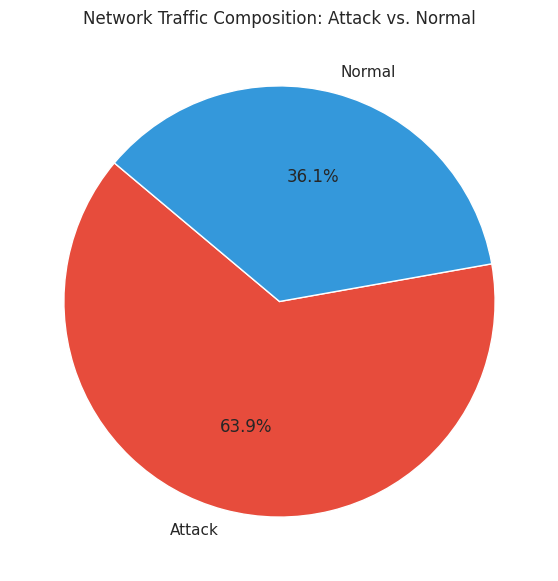

In [7]:
plt.figure(figsize=(7,7))
df['label'].value_counts().plot.pie(autopct='%1.1f%%', labels=['Attack', 'Normal'], colors=['#e74c3c','#3498db'], startangle=140)
plt.title('Network Traffic Composition: Attack vs. Normal')
plt.ylabel('')
plt.show()

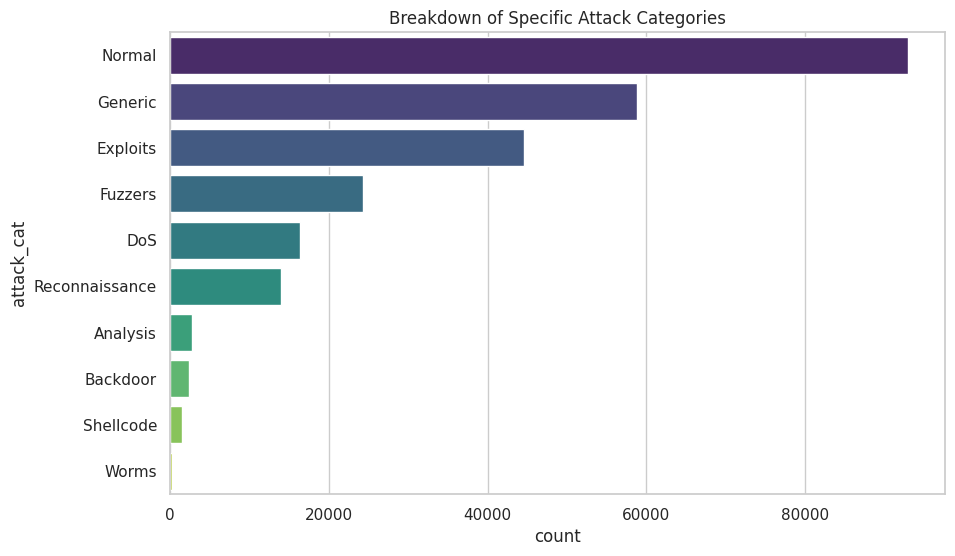

In [8]:
plt.figure()
sns.countplot(y='attack_cat', data=df, palette='viridis', order=df['attack_cat'].value_counts().index)
plt.title('Breakdown of Specific Attack Categories')
plt.show()

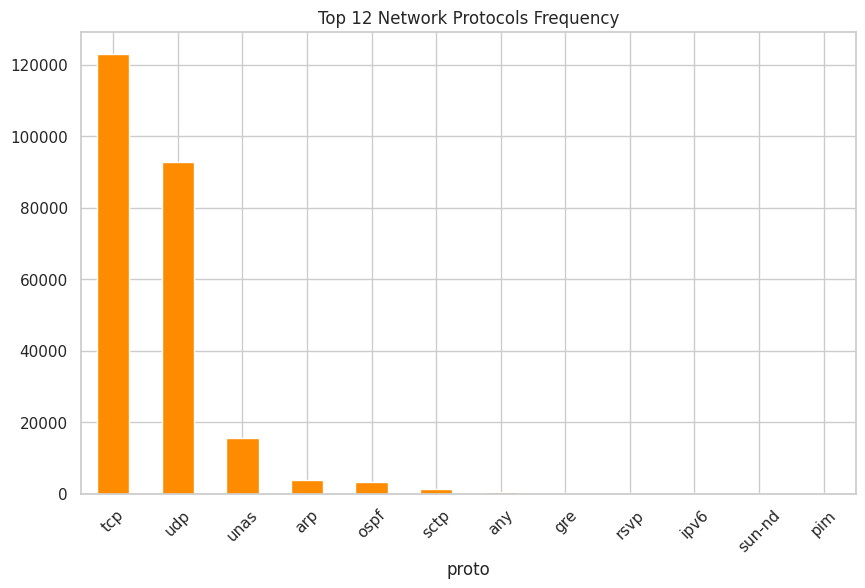

In [9]:
plt.figure()
df['proto'].value_counts().head(12).plot(kind='bar', color='darkorange')
plt.title('Top 12 Network Protocols Frequency')
plt.xticks(rotation=45)
plt.show()

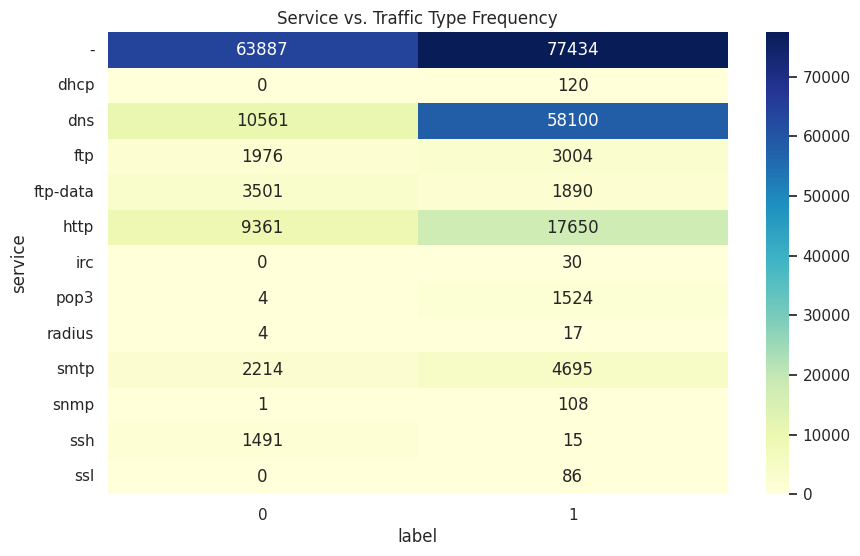

In [11]:
plt.figure(figsize=(10, 6))
service_label = pd.crosstab(df['service'], df['label'])
sns.heatmap(service_label, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Service vs. Traffic Type Frequency')
plt.show()

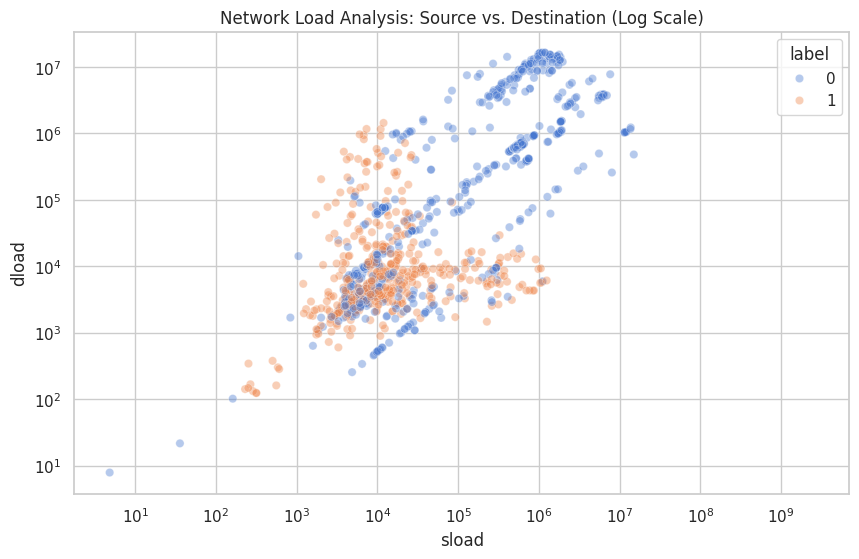

In [12]:
plt.figure()
sns.scatterplot(x='sload', y='dload', hue='label', data=df.sample(2000), alpha=0.4)
plt.xscale('log')
plt.yscale('log')
plt.title('Network Load Analysis: Source vs. Destination (Log Scale)')
plt.show()

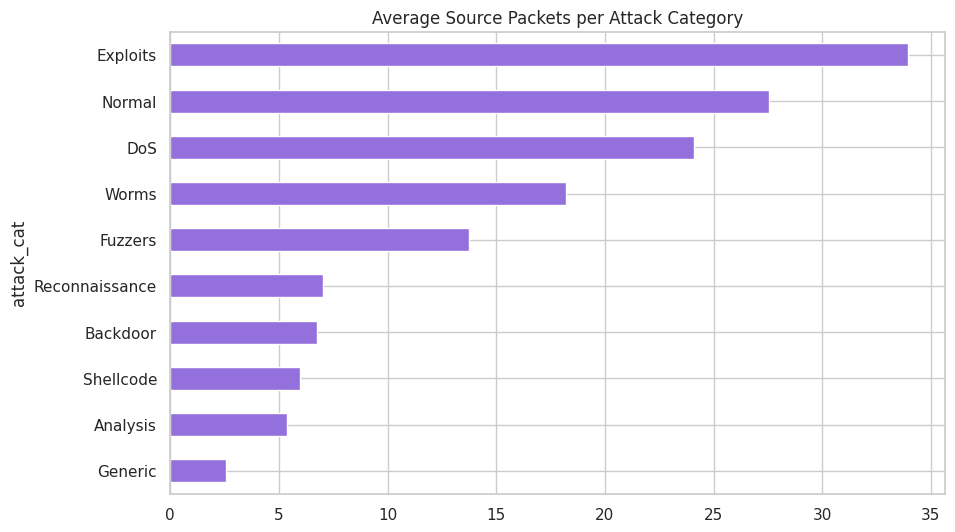

In [13]:
plt.figure()
df.groupby('attack_cat')['spkts'].mean().sort_values().plot(kind='barh', color='mediumpurple')
plt.title('Average Source Packets per Attack Category')
plt.show()

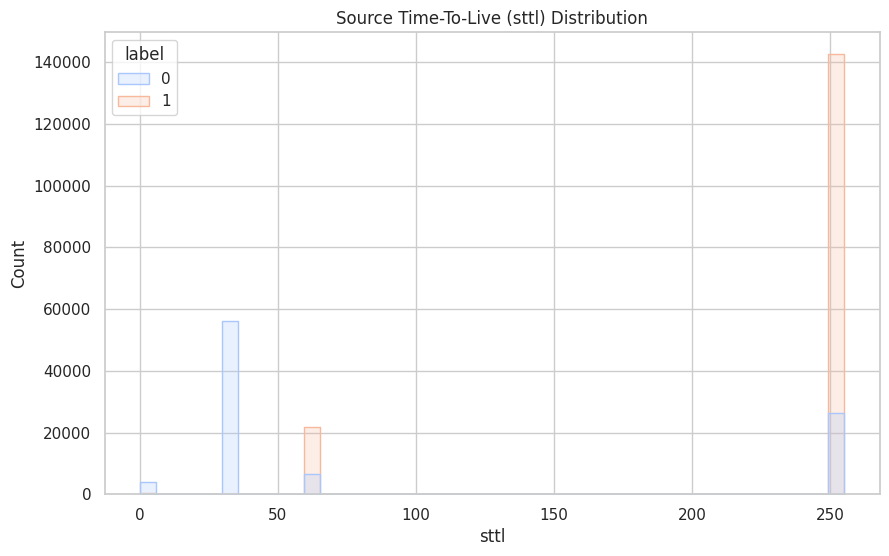

In [14]:
plt.figure()
sns.histplot(df, x='sttl', hue='label', element='step', palette='coolwarm')
plt.title('Source Time-To-Live (sttl) Distribution')
plt.show()

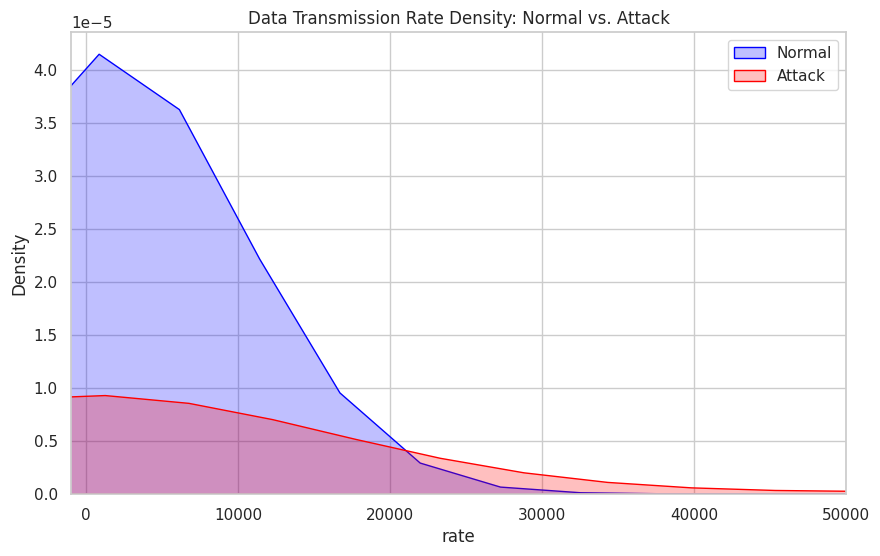

In [16]:
plt.figure()
sns.kdeplot(df[df['label']==0]['rate'], label='Normal', fill=True, color='blue')
sns.kdeplot(df[df['label']==1]['rate'], label='Attack', fill=True, color='red')
plt.title('Data Transmission Rate Density: Normal vs. Attack')
plt.xlim(-1000, 50000)
plt.legend()
plt.show()

In [17]:
# -----------------------------------------------------------------------------
# STEP 3: PRE-PROCESSING & MANUAL OVERSAMPLING
# -----------------------------------------------------------------------------
# Processing a balanced sample for optimal resource usage
df_sample = df.sample(n=min(len(df), 50000), random_state=42)

# Encoding categorical columns
le = LabelEncoder()
for col in ['proto', 'service', 'state']:
    df_sample[col] = le.fit_transform(df_sample[col].astype(str))

# Define Features (X) and Target (y)
X = df_sample.drop(['label', 'attack_cat'], axis=1)
y = df_sample['label']

# Initial Split
X_train_raw, X_test, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- MANUAL RANDOM OVERSAMPLING ---
train_data = pd.concat([X_train_raw, y_train_raw], axis=1)
# Identify minority and majority (In this sample, Normal is usually the minority)
df_maj = train_data[train_data.label == 1]
df_min = train_data[train_data.label == 0]

# Oversample minority to match majority
df_min_upsampled = resample(df_min, replace=True, n_samples=len(df_maj), random_state=42)
train_balanced = pd.concat([df_maj, df_min_upsampled])

X_train = train_balanced.drop('label', axis=1)
y_train = train_balanced['label']

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
# -----------------------------------------------------------------------------
# STEP 4: MODEL TRAINING (GRADIENT BOOSTING & NAIVE BAYES)
# -----------------------------------------------------------------------------
results = []

# --- Model 1: Gradient Boosting ---
print("\nTraining Gradient Boosting Model...")
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train_scaled, y_train)
gb_preds = gb.predict(X_test_scaled)

results.append({
    "Algorithm": "Gradient Boosting",
    "Accuracy": round(accuracy_score(y_test, gb_preds), 4),
    "Precision": round(precision_score(y_test, gb_preds), 4),
    "Recall": round(recall_score(y_test, gb_preds), 4),
    "F1-Score": round(f1_score(y_test, gb_preds), 4)
})

# --- Model 2: Gaussian Naïve Bayes ---
print("Training Naïve Bayes Model...")
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
nb_preds = nb.predict(X_test_scaled)

results.append({
    "Algorithm": "Naïve Bayes",
    "Accuracy": round(accuracy_score(y_test, nb_preds), 4),
    "Precision": round(precision_score(y_test, nb_preds), 4),
    "Recall": round(recall_score(y_test, nb_preds), 4),
    "F1-Score": round(f1_score(y_test, nb_preds), 4)
})


Training Gradient Boosting Model...
Training Naïve Bayes Model...


In [19]:
# -----------------------------------------------------------------------------
# STEP 5: FINAL PERFORMANCE RANK TABLE
# -----------------------------------------------------------------------------
rank_table = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
rank_table.index += 1
rank_table.index.name = "Rank"

print("\n" + "="*75)
print("STUDENT 3: MACHINE LEARNING PERFORMANCE RANK TABLE")
print("="*75)
print(rank_table)


STUDENT 3: MACHINE LEARNING PERFORMANCE RANK TABLE
              Algorithm  Accuracy  Precision  Recall  F1-Score
Rank                                                          
1     Gradient Boosting    0.9380     0.9709  0.9306    0.9503
2           Naïve Bayes    0.8117     0.8814  0.8140    0.8464


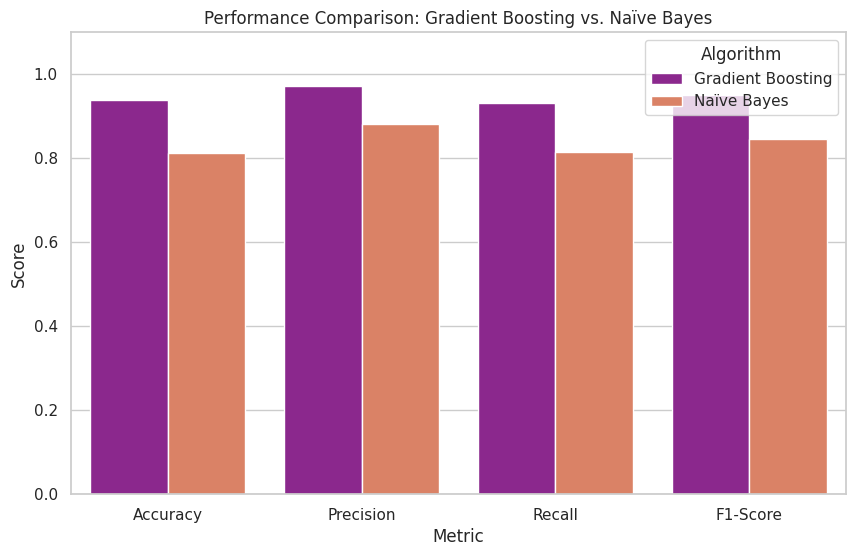

In [20]:
# Visual Comparison of Final Metrics
plt.figure()
melted = rank_table.melt(id_vars='Algorithm', var_name='Metric', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Algorithm', data=melted, palette='plasma')
plt.title('Performance Comparison: Gradient Boosting vs. Naïve Bayes')
plt.ylim(0, 1.1)
plt.show()